# FitzHugh-Nagumo profile likelihood vs sampling rate (`a` unknown)

This notebook studies how the observation sampling rate affects the profile likelihood of the unknown FitzHugh-Nagumo parameter `a`, while keeping all other model components fixed.

We use `ContinuousTimeEnKF` to approximate the marginal log-likelihood for each fixed `a` value.

## Setup

- Dynamical model: continuous-time FitzHugh-Nagumo SDE
- Unknown parameter: `a`
- True value used for synthetic data: `a_true = 0.08`
- Time horizon: `T = 20`
- Sampling rates (seconds): `[1e-1, 1.0]`

In [12]:
import time
import numpy as np
from jax import config as jax_config

# Toggle precision here.
USE_X64 = False
jax_config.update('jax_enable_x64', USE_X64)

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from jax import grad, vmap

import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import DynamicalModel, Filter, SDESimulator
from dynestyx.models import ContinuousTimeStateEvolution, LinearGaussianObservation
from dynestyx.inference.filters import ContinuousTimeEnKFConfig, ContinuousTimeDPFConfig

print('jax_enable_x64 =', USE_X64)
print('dtype example:', jnp.array(1.0).dtype)

jax_enable_x64 = False
dtype example: float32


In [ ]:
def fhn_model(obs_times=None, obs_values=None):
    # a is the only unknown parameter in this study.
    a = numpyro.sample('a', dist.Uniform(0.01, 0.2))

    # Fixed FHN constants
    b = 0.7
    c = 0.8
    I_ext = 0.5

    state_dim = 2
    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(state_dim),
            covariance_matrix=jnp.eye(state_dim),
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: jnp.array([
                x[0] - (1.0 / 3.0) * x[0]**3 - x[1] + I_ext,
                a * (x[0] + b - c * x[1]),
            ]),
            diffusion_coefficient=lambda x, u, t: 0.001 * jnp.eye(state_dim),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(state_dim),
            R=(0.01 **2 ) * jnp.eye(state_dim),
        ),
    )
    return dsx.sample('f', dynamics, obs_times=obs_times, obs_values=obs_values)

## Generate one high-rate synthetic dataset and downsample

Base observation shape: (1000, 2)
Base time points: 1000


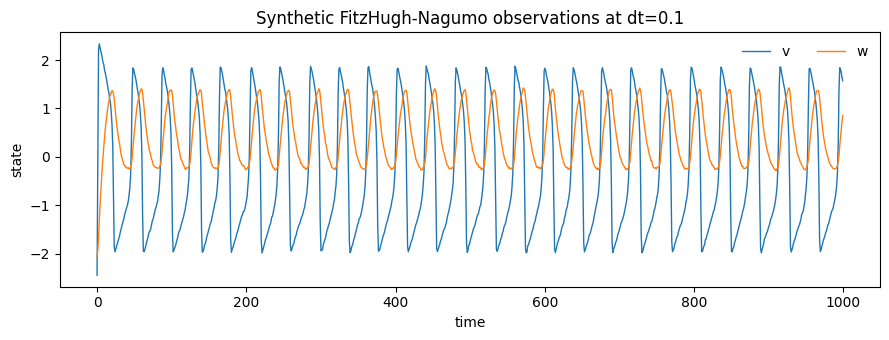

In [14]:
T = 1000.0
sample_rates = [1.0, 10.0, 100.0]
base_dt = 1.0
a_true = 0.08

base_times = jnp.arange(0.0, T, base_dt)

key = jr.PRNGKey(0)
predictive = Predictive(
    fhn_model,
    params={'a': jnp.array(a_true)},
    num_samples=1,
    exclude_deterministic=False,
)

with SDESimulator(dt0=0.1):
    sim = predictive(key, obs_times=base_times)

base_obs = sim['observations'].squeeze(0)
base_states = sim['states'].squeeze(0)

print('Base observation shape:', base_obs.shape)
print('Base time points:', base_times.shape[0])

plt.figure(figsize=(9, 3.5))
for i, name in enumerate(['v', 'w']):
    plt.plot(np.asarray(base_times), np.asarray(base_obs)[:, i], lw=1, label=name)
plt.title('Synthetic FitzHugh-Nagumo observations at dt=0.1')
plt.xlabel('time')
plt.ylabel('state')
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

In [15]:
def downsample_from_base(dt):
    step = int(round(dt / base_dt))
    if not np.isclose(step * base_dt, dt):
        raise ValueError(f'dt={dt} is not an integer multiple of base_dt={base_dt}')
    return base_times[::step], base_obs[::step]

for dt in sample_rates:
    t_dt, y_dt = downsample_from_base(dt)
    print(f'dt={dt:<6g} -> n_obs={t_dt.shape[0]}')

dt=1      -> n_obs=1000
dt=10     -> n_obs=100
dt=100    -> n_obs=10


## Profile likelihood helper (`ContinuousTimeEnKF`)
The deterministic site `f_marginal_loglik` is added by `Filter` backends.

In [16]:
def mll_at_a(a, obs_times, obs_values, filter_config, key):
    def filtered_model(obs_times=None, obs_values=None):
        with Filter(filter_config=filter_config):
            return fhn_model(obs_times=obs_times, obs_values=obs_values)

    conditioned = numpyro.handlers.condition(
        filtered_model,
        data={'a': a},
    )
    tr = numpyro.handlers.trace(numpyro.handlers.seed(conditioned, key)).get_trace(
        obs_times=obs_times,
        obs_values=obs_values,
    )
    return tr['f_marginal_loglik']['value']


def finite_difference_grad(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return np.gradient(y, x, edge_order=2)


def profile_and_grad_for_dt(dt, a_grid, n_particles=25, seed=123):
    obs_times, obs_values = downsample_from_base(dt)
    cfg = ContinuousTimeEnKFConfig(n_particles=n_particles, crn_seed=jr.PRNGKey(seed), diffeqsolve_dt0=0.1, diffeqsolve_max_steps=10_000)
    key = jr.PRNGKey(seed)

    mll_fn = lambda aval: mll_at_a(aval, obs_times, obs_values, cfg, key)

    t0 = time.perf_counter()
    profile = vmap(mll_fn)(a_grid)
    grad_profile = vmap(grad(mll_fn))(a_grid)
    elapsed = time.perf_counter() - t0

    profile_np = np.asarray(profile)
    grad_profile_np = np.asarray(grad_profile)
    fd_grad_profile_np = finite_difference_grad(np.asarray(a_grid), profile_np)

    return profile_np, grad_profile_np, fd_grad_profile_np, elapsed, obs_times.shape[0]

## Compute profiles for each sample rate

In [17]:
# Denser evaluation grid (0.001 spacing).
grid_space = 0.001
a_grid = jnp.arange(0.01, 0.2 + grid_space, grid_space)

profiles = {}
grad_profiles = {}
fd_grad_profiles = {}
meta = {}

for i, dt in enumerate(sample_rates):
    prof, grad_prof, fd_grad_prof, elapsed, n_obs = profile_and_grad_for_dt(
        dt=dt,
        a_grid=a_grid,
        n_particles=25,
        seed=100 + i,
    )
    profiles[dt] = prof
    grad_profiles[dt] = grad_prof
    fd_grad_profiles[dt] = fd_grad_prof
    meta[dt] = {'elapsed_s': elapsed, 'n_obs': int(n_obs)}
    print(f'dt={dt:<6g} | n_obs={n_obs:<6d} | elapsed={elapsed:6.2f}s')

dt=1      | n_obs=1000   | elapsed=  7.17s
dt=10     | n_obs=100    | elapsed=  5.81s
dt=100    | n_obs=10     | elapsed=  6.45s


## Plot profile likelihoods colored by sample rate

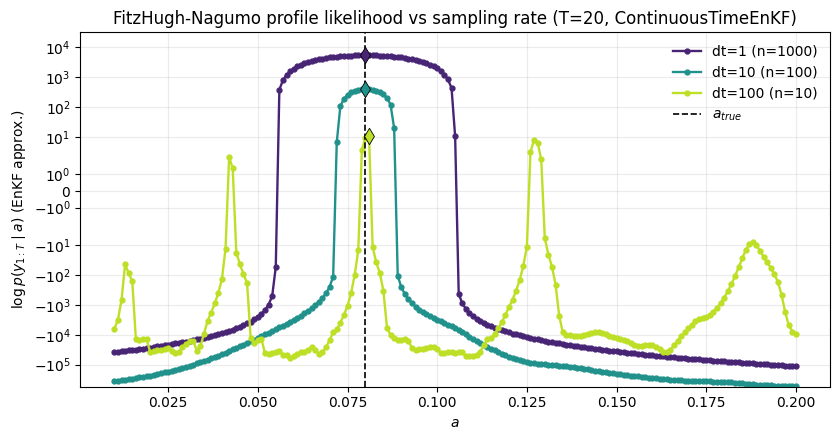

In [18]:
plt.figure(figsize=(8.5, 4.5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(sample_rates)))

for c, dt in zip(colors, sample_rates):
    y = profiles[dt]
    plt.plot(
        np.asarray(a_grid),
        y,
        marker='o',
        ms=3.5,
        lw=1.7,
        color=c,
        label=f'dt={dt:g} (n={meta[dt]["n_obs"]})',
    )
    i_star = int(np.argmax(y))
    a_hat = float(a_grid[i_star])
    y_hat = float(y[i_star])


    plt.scatter([a_hat], [y_hat], marker='d',color=c, s=70, edgecolors='black', linewidth=0.6, zorder=5)

plt.axvline(a_true, color='k', ls='--', lw=1.2, label=r'$a_{true}$')
plt.xlabel(r'$a$')
plt.ylabel(r'$\log p(y_{1:T} \mid a)$ (EnKF approx.)')
plt.yscale('symlog')
# plt.ylim(top=0)
plt.title('FitzHugh-Nagumo profile likelihood vs sampling rate (T=20, ContinuousTimeEnKF)')
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()

plt.show()

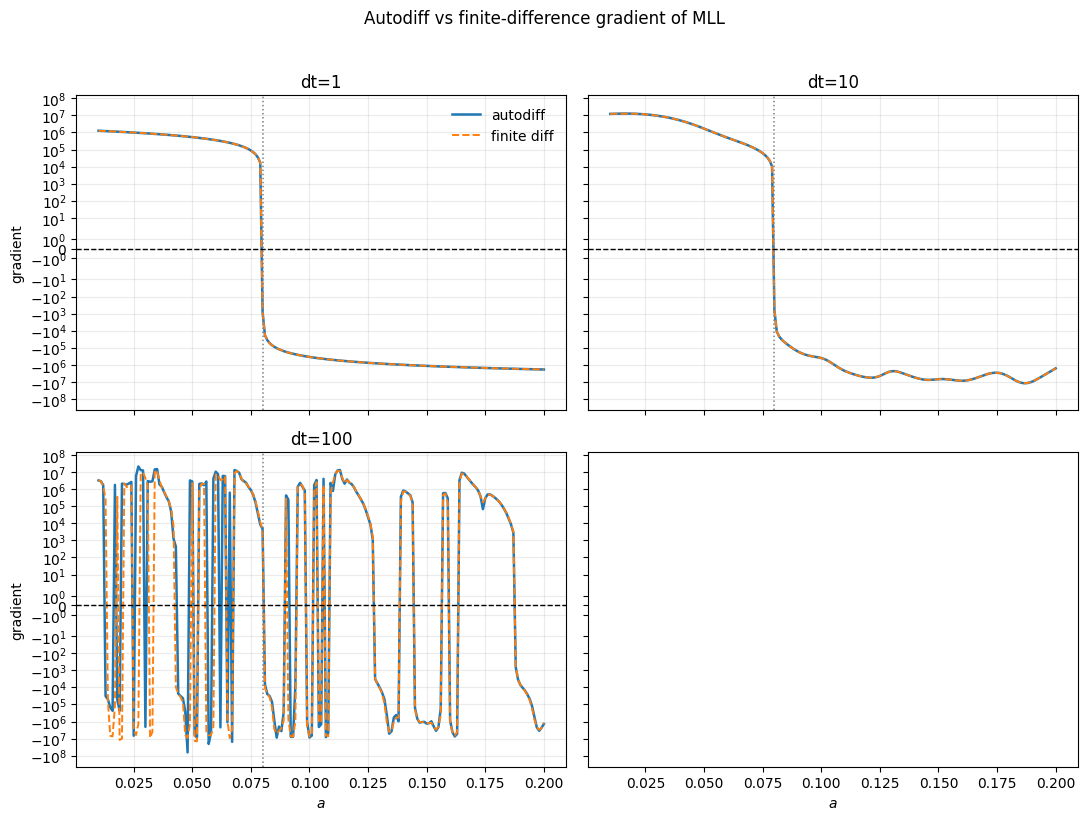

Relative percent error summary (mean over grid):
dt=1      | RPE(auto | fd truth)=    0.005% | RPE(fd | auto truth)=    0.005%
dt=10     | RPE(auto | fd truth)=    0.356% | RPE(fd | auto truth)=    0.349%
dt=100    | RPE(auto | fd truth)=   61.098% | RPE(fd | auto truth)=  218.994%


In [19]:
# Compare autodiff and finite-difference gradient estimates across sample rates.
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, dt in zip(axes, sample_rates):
    g_auto = np.asarray(grad_profiles[dt])
    g_fd = np.asarray(fd_grad_profiles[dt])

    ax.plot(np.asarray(a_grid), g_auto, lw=1.8, label='autodiff', color='tab:blue')
    ax.plot(np.asarray(a_grid), g_fd, lw=1.4, ls='--', label='finite diff', color='tab:orange')
    ax.axhline(0.0, color='k', ls='--', lw=1.0)
    ax.axvline(a_true, color='gray', ls=':', lw=1.1)
    ax.set_title(f'dt={dt:g}')
    ax.grid(alpha=0.25)
    ax.set_yscale('symlog')

axes[0].set_ylabel('gradient')
axes[2].set_ylabel('gradient')
axes[2].set_xlabel(r'$a$')
axes[3].set_xlabel(r'$a$')
axes[0].legend(frameon=False)
fig.suptitle('Autodiff vs finite-difference gradient of MLL', y=1.02)
plt.tight_layout()
plt.show()

# Relative percent errors in both directions (treat each as truth).
print('Relative percent error summary (mean over grid):')
for dt in sample_rates:
    g_auto = np.asarray(grad_profiles[dt], dtype=float)
    g_fd = np.asarray(fd_grad_profiles[dt], dtype=float)

    eps = 1e-12
    rpe_fd_as_truth = 100.0 * np.mean(np.abs(g_auto - g_fd) / np.maximum(np.abs(g_fd), eps))
    rpe_auto_as_truth = 100.0 * np.mean(np.abs(g_fd - g_auto) / np.maximum(np.abs(g_auto), eps))

    print(
        f'dt={dt:<6g} | RPE(auto | fd truth)={rpe_fd_as_truth:9.3f}% | '
        f'RPE(fd | auto truth)={rpe_auto_as_truth:9.3f}%'
    )

Using CLIP_NORM=1


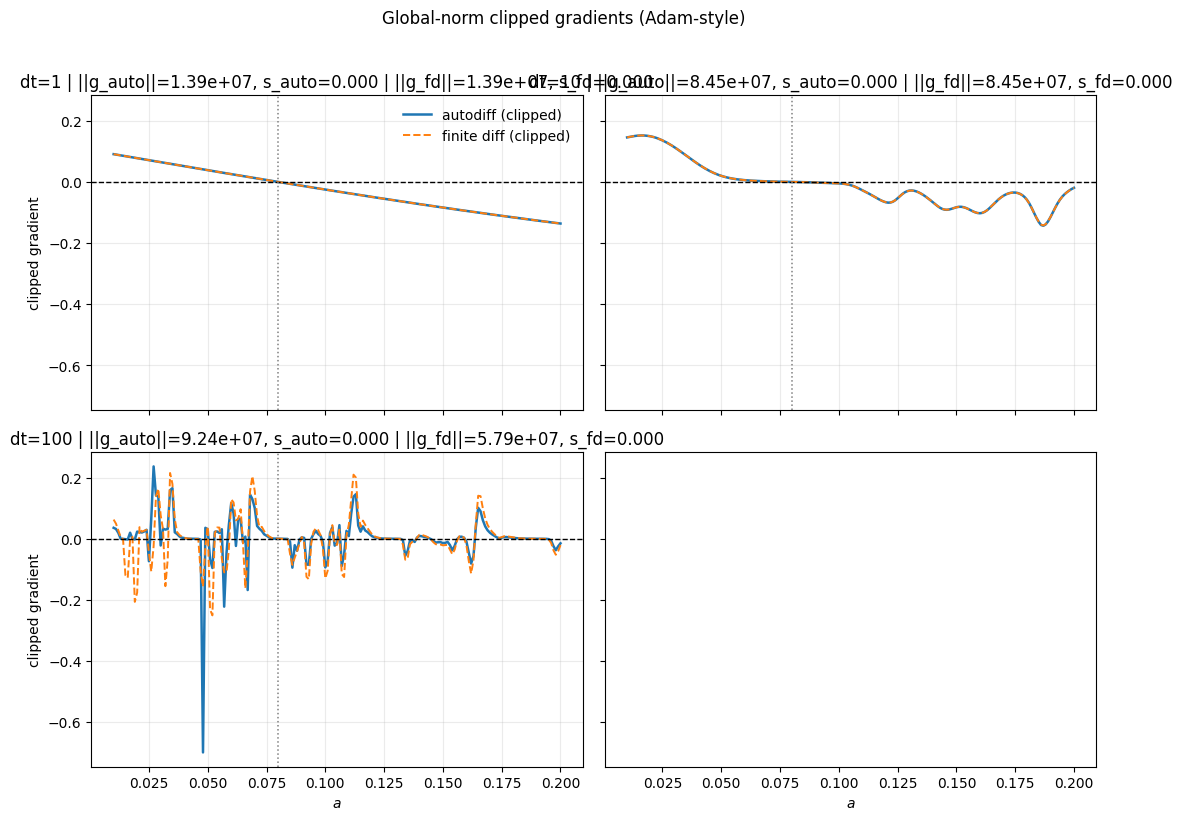

In [20]:
# Gradient clipping comparison (global-norm style, as used in optimizers like Adam).
CLIP_NORM = 1.0  # tune as needed

def clip_by_global_norm(g, clip_norm):
    g = np.asarray(g, dtype=float)
    norm = np.linalg.norm(g)
    scale = min(1.0, clip_norm / max(norm, 1e-12))
    return g * scale, norm, scale

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.ravel()

print(f'Using CLIP_NORM={CLIP_NORM:g}')
for ax, dt in zip(axes, sample_rates):
    g_auto = np.asarray(grad_profiles[dt], dtype=float)
    g_fd = np.asarray(fd_grad_profiles[dt], dtype=float)

    g_auto_clip, auto_norm, auto_scale = clip_by_global_norm(g_auto, CLIP_NORM)
    g_fd_clip, fd_norm, fd_scale = clip_by_global_norm(g_fd, CLIP_NORM)

    ax.plot(np.asarray(a_grid), g_auto_clip, lw=1.8, label='autodiff (clipped)', color='tab:blue')
    ax.plot(np.asarray(a_grid), g_fd_clip, lw=1.4, ls='--', label='finite diff (clipped)', color='tab:orange')
    ax.axhline(0.0, color='k', ls='--', lw=1.0)
    ax.axvline(a_true, color='gray', ls=':', lw=1.1)
    ax.set_title(
        f'dt={dt:g} | ||g_auto||={auto_norm:.2e}, s_auto={auto_scale:.3f} | '
        f'||g_fd||={fd_norm:.2e}, s_fd={fd_scale:.3f}'
    )
    ax.grid(alpha=0.25)

axes[0].set_ylabel('clipped gradient')
axes[2].set_ylabel('clipped gradient')
axes[2].set_xlabel(r'$a$')
axes[3].set_xlabel(r'$a$')
axes[0].legend(frameon=False)
fig.suptitle('Global-norm clipped gradients (Adam-style)', y=1.02)
plt.tight_layout()
plt.show()

Using CLIP_VALUE=1


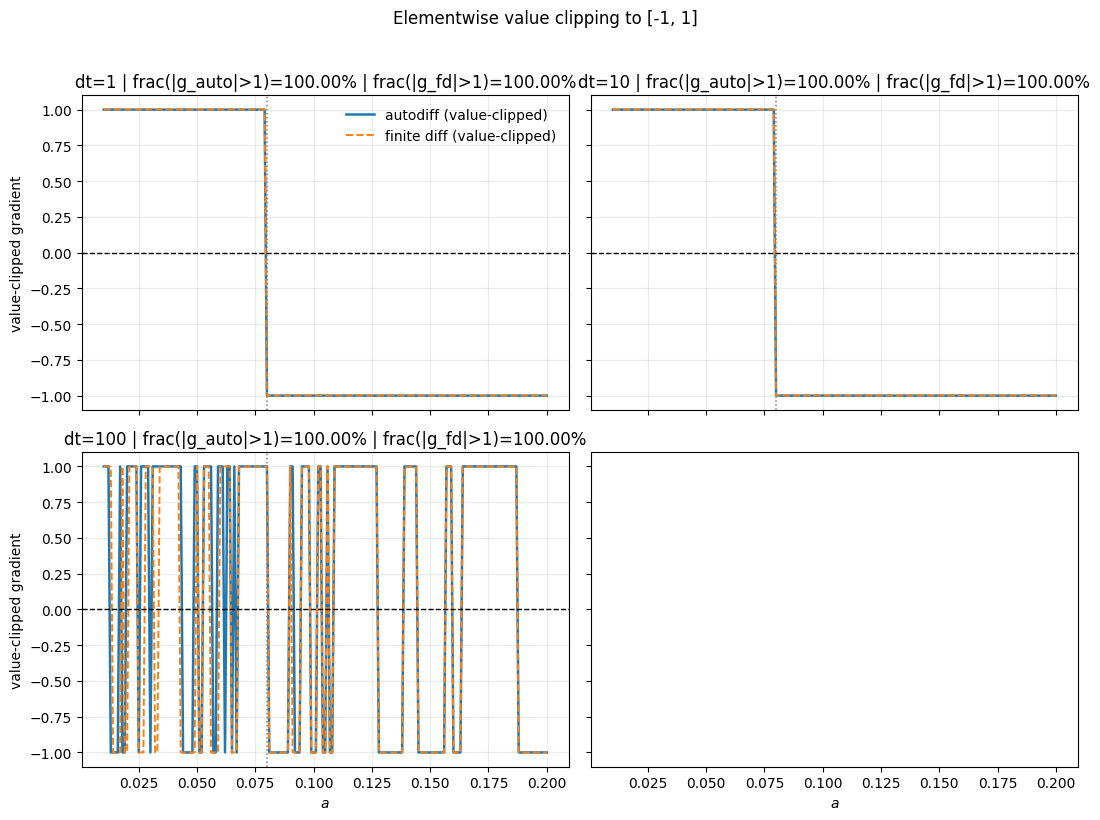

In [21]:
# Simple elementwise clipping (scale cap): clip each gradient entry to [-1, 1].
CLIP_VALUE = 1.0

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.ravel()

print(f'Using CLIP_VALUE={CLIP_VALUE:g}')
for ax, dt in zip(axes, sample_rates):
    g_auto = np.asarray(grad_profiles[dt], dtype=float)
    g_fd = np.asarray(fd_grad_profiles[dt], dtype=float)

    g_auto_clip = np.clip(g_auto, -CLIP_VALUE, CLIP_VALUE)
    g_fd_clip = np.clip(g_fd, -CLIP_VALUE, CLIP_VALUE)

    auto_frac = np.mean(np.abs(g_auto) > CLIP_VALUE)
    fd_frac = np.mean(np.abs(g_fd) > CLIP_VALUE)

    ax.plot(np.asarray(a_grid), g_auto_clip, lw=1.8, label='autodiff (value-clipped)', color='tab:blue')
    ax.plot(np.asarray(a_grid), g_fd_clip, lw=1.4, ls='--', label='finite diff (value-clipped)', color='tab:orange')
    ax.axhline(0.0, color='k', ls='--', lw=1.0)
    ax.axvline(a_true, color='gray', ls=':', lw=1.1)
    ax.set_title(
        f'dt={dt:g} | frac(|g_auto|>1)={auto_frac:.2%} | frac(|g_fd|>1)={fd_frac:.2%}'
    )
    ax.grid(alpha=0.25)

axes[0].set_ylabel('value-clipped gradient')
axes[2].set_ylabel('value-clipped gradient')
axes[2].set_xlabel(r'$a$')
axes[3].set_xlabel(r'$a$')
axes[0].legend(frameon=False)
fig.suptitle('Elementwise value clipping to [-1, 1]', y=1.02)
plt.tight_layout()
plt.show()

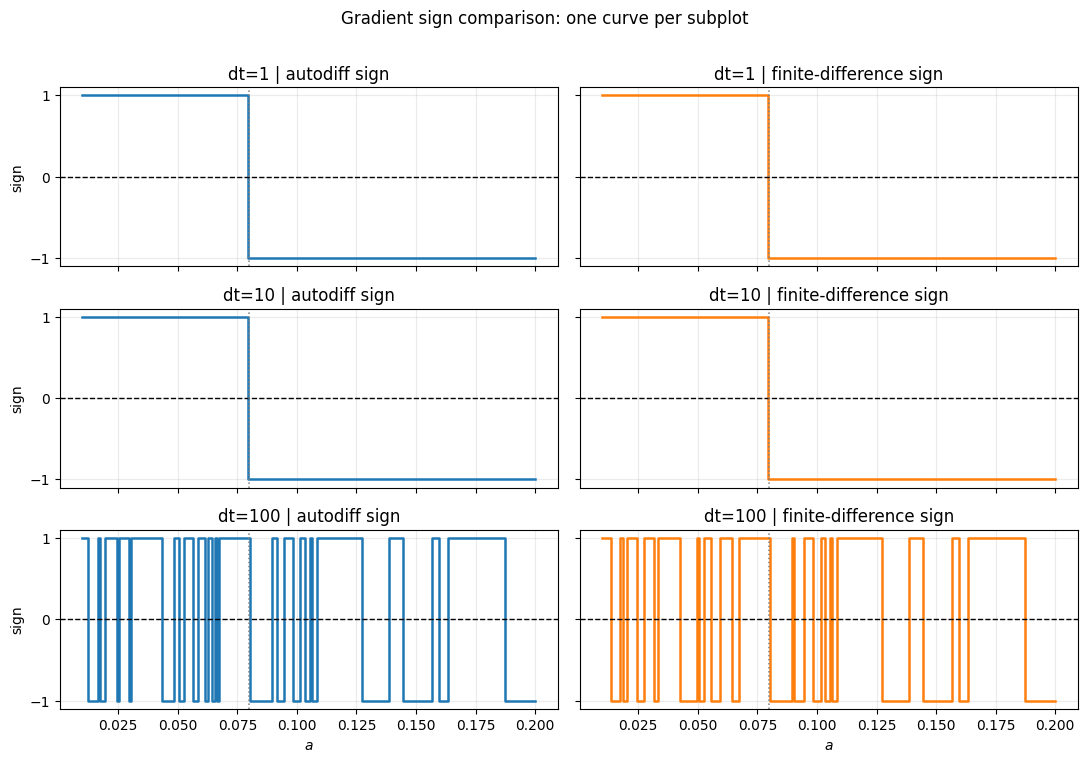

Sign agreement between autodiff and finite-difference:
dt=1      | sign agreement=100.00%
dt=10     | sign agreement=100.00%
dt=100    | sign agreement=91.62%


In [22]:
# Sign-only comparison per sample rate: two panels per dt (autodiff vs finite diff).
n_dt = len(sample_rates)
fig, axes = plt.subplots(n_dt, 2, figsize=(11, 2.5 * n_dt), sharex=True, sharey=True)

if n_dt == 1:
    axes = np.asarray([axes])

for i, dt in enumerate(sample_rates):
    x = np.asarray(a_grid)
    s_auto = np.sign(np.asarray(grad_profiles[dt], dtype=float))
    s_fd = np.sign(np.asarray(fd_grad_profiles[dt], dtype=float))

    ax_auto = axes[i, 0]
    ax_fd = axes[i, 1]

    ax_auto.step(x, s_auto, where='mid', lw=1.8, color='tab:blue')
    ax_auto.axhline(0.0, color='k', ls='--', lw=1.0)
    ax_auto.axvline(a_true, color='gray', ls=':', lw=1.1)
    ax_auto.set_title(f'dt={dt:g} | autodiff sign')
    ax_auto.set_ylabel('sign')
    ax_auto.set_yticks([-1, 0, 1])
    ax_auto.grid(alpha=0.25)

    ax_fd.step(x, s_fd, where='mid', lw=1.8, color='tab:orange')
    ax_fd.axhline(0.0, color='k', ls='--', lw=1.0)
    ax_fd.axvline(a_true, color='gray', ls=':', lw=1.1)
    ax_fd.set_title(f'dt={dt:g} | finite-difference sign')
    ax_fd.set_yticks([-1, 0, 1])
    ax_fd.grid(alpha=0.25)

axes[-1, 0].set_xlabel(r'$a$')
axes[-1, 1].set_xlabel(r'$a$')
fig.suptitle('Gradient sign comparison: one curve per subplot', y=1.01)
plt.tight_layout()
plt.show()

# Compact sign-consistency score by sample rate.
print('Sign agreement between autodiff and finite-difference:')
for dt in sample_rates:
    s_auto = np.sign(np.asarray(grad_profiles[dt], dtype=float))
    s_fd = np.sign(np.asarray(fd_grad_profiles[dt], dtype=float))
    agreement = np.mean(s_auto == s_fd)
    print(f'dt={dt:<6g} | sign agreement={agreement:.2%}')